In [5]:
!tar -xzf ./data/github_recommender_paper_with_repository.tar.gz -C ./data

In [6]:
!head ./data/github_readme_similarity.txt

ID	URL	Username	Name	Readme	Topics	Title	Starred	Branch	LastUpdate
1723826	https://github.com/coallaoh/AIP	coallaoh	AIP	"Adversarial Image Perturbation for Privacy Protection &ndash; A Game Theory Perspective, ICCV&rsquo;17
Seong Joon Oh, Mario Fritz, Bernt Schiele.
Max-Planck Institute for Informatics.
, ICCV&rsquo;17
Users like sharing personal photos with others through social media. At the same time, they might want to make automatic identification in such photos difficult or even impossible. Classic obfuscation methods such as blurring are not only unpleasant but also not as effective as one would expect. Recent studies on adversarial image perturbations (AIP) suggest that it is possible to confuse recognition systems effectively without unpleasant artifacts. However, in the presence of counter measures against AIPs, it is unclear how effective AIP would be in particular when the choice of counter measure is unknown. Game theory provides tools for studying the interaction between 

In [ ]:
%matplotlib inline

import pandas as pd

In [1]:
df = pd.read_csv('./data/github_readme_similarity.txt', sep='\t')
df['Topics'] = df['Topics'].map(lambda x: x.split(',') if isinstance(x, str) else x)
df['Starred'] = df['Starred'].map(lambda x: int(x.split('=')[-1].split(')')[0]))
df['LastUpdate'] = df['LastUpdate'].map(lambda x: map(int, x.split('-'))).map(list).map(lambda x: pd.datetime(x[0], x[2], x[1]))
df

,ID,URL,Username,Name,Readme,Topics,Title,Starred,Branch,LastUpdate
0,1723826,https://github.com/coallaoh/AIP,coallaoh,AIP,Adversarial Image Perturbation for Privacy Pro...,NaN,A Joint Intrinsic-Extrinsic Prior Model for Re...,11,master,2020-08-22
1,3327143,https://github.com/codeaudit/AIP,codeaudit,AIP,Adversarial Image Perturbation for Privacy Pro...,NaN,由于1.0gdinoj代码十分糟糕，这里打算进行重构。由于时间的关系，不会大规模改动架构,0,master,2020-09-01
2,40919,https://github.com/yiguanxian/speech-emotion-r...,yiguanxian,speech-emotion-research,speech-emotion-research\nThis repository conta...,NaN,Keras implementation of ''Speech Emotion Recog...,0,master,2020-07-19
3,1538136,https://github.com/facebookresearch/impact-dri...,facebookresearch,impact-driven-exploration,RIDE: Rewarding Impact-Driven Exploration for ...,NaN,github.com/facebookresearch/impact-driven-expl...,44,master,2020-08-20
4,35380,https://github.com/debanjanghosh/sarcasm_context,debanjanghosh,sarcasm_context,sarcasm_context\nRole of conversation context ...,NaN,Conversation Context for Sarcasm Detection in ...,6,master,2020-07-17
5,1538137,https://github.com/Alex-Fabbri/deep_learning_n...,Alex-Fabbri,deep_learning_nlp_sarcasm,deep_learning_nlp_sarcasm\nCode for the paper:...,NaN,github.com/Alex-Fabbri/deep_learning_nlp_sarca...,7,master,2020-08-22
6,1538134,https://github.com/LIBOL/SOL,LIBOL,SOL,SOL - A Library for Scalable Online Learning A...,NaN,github.com/LIBOL/SOL - Paper2code,87,master,2020-08-20
7,3957966,https://github.com/459548764/Pairwise-Indepenc...,459548764,Pairwise-Indepence-Autoencoder,Pairwise-Indepence-Autoencoder: learning disen...,NaN,Image Style Transfer Using Convolutional Neura...,5,master,2020-09-08
8,1538139,https://github.com/Aida-Rahmattalabi/Fair-and-...,Aida-Rahmattalabi,Fair-and-Robust-Graph-Covering-Problem,Fair-and-Robust-Graph-Covering-Problem\nFair a...,NaN,github.com/Aida-Rahmattalabi/Fair-and-Robust-G...,0,master,2020-08-21
9,2784854,https://github.com/amirunpri2018/Visual-Featur...,amirunpri2018,Visual-Feature-Attribution-Using-Wasserstein-G...,PyTorch implementation of VAGAN: Visual Featur...,NaN,A curated list of awesome resources for design...,2,master,2020-08-27


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262071 entries, 0 to 262070
Data columns (total 10 columns):
ID            262071 non-null int64
URL           262071 non-null object
Username      262071 non-null object
Name          262071 non-null object
Readme        262053 non-null object
Topics        17001 non-null object
Title         245772 non-null object
Starred       262071 non-null int64
Branch        261407 non-null object
LastUpdate    262071 non-null datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 20.0+ MB


In [4]:
df.duplicated(['ID', 'URL', 'Username', 'Name', 'Readme', 'Title', 'Starred', 'Branch', 'LastUpdate']).sum()

298

In [13]:
tmp_s = df['ID'].value_counts()
print((tmp_s - 1).sum())
tmp_s

298


201        8
9965       4
1403       4
7013       4
2          3
4          3
7906       3
3          3
213        2
69         2
101        2
12         2
174        2
166        2
19         2
196        2
242        2
67         2
87         2
97         2
116        2
91         2
189        2
75         2
262        2
136        2
239        2
139        2
255        2
167        2
          ..
1545305    1
3640410    1
2702476    1
2504358    1
2694280    1
2162818    1
83075      1
1546184    1
3470106    1
437374     1
3060861    1
3714384    1
4099194    1
3579000    1
3601525    1
3589235    1
971889     1
3071088    1
4072559    1
3550318    1
3021928    1
4090982    1
3099615    1
4084833    1
1549407    1
1551454    1
1553501    1
1555548    1
1541211    1
526337     1
Name: ID, Length: 261773, dtype: int64

In [14]:
df = df.drop_duplicates('ID').reset_index(drop=True)
df.shape

(261773, 10)

In [15]:
df['Username'].value_counts()

shubhampachori12110095    2145
ml-lab                    1693
afcarl                    1685
BenJamesbabala            1199
codeaudit                 1158
stjordanis                1143
amirunpri2018             1007
hyzcn                      992
fendaq                     740
liuguoyou                  641
PeterZhouSZ                621
Pandinosaurus              613
phymucs                    611
johndpope                  590
reinforcementdriving       576
jtpils                     548
wanjinchang                546
qianrenjian                524
templeblock                503
colinsongf                 490
zgsxwsdxg                  488
lilujunai                  487
yyht                       475
StevenLOL                  470
peternara                  459
vyraun                     425
GSRS                       420
AmmieQi                    397
caomw                      397
facebookresearch           391
                          ... 
brando130                    1
ieriii  

In [16]:
df['Name'].value_counts()

caffe                                              1217
Mask_RCNN                                           857
transformers                                        747
bert                                                650
gym                                                 560
pytorch-CycleGAN-and-pix2pix                        555
Deep-Learning-Papers-Reading-Roadmap                552
reinforcement-learning                              542
Detectron                                           524
fairseq                                             521
mmdetection                                         457
tensor2tensor                                       380
awesome-deep-learning-papers                        380
darknet                                             367
generative-models                                   358
fastText                                            349
pytorch-pretrained-BERT                             338
awesome-deep-vision                             

In [17]:
df['Topics'].dropna().map(len).describe(percentiles=[.01, .05, .1, .25, .5, .75, .8, .85, .86, .87, .9, .95, .99])

count    16846.000000
mean         5.753888
std          3.569682
min          1.000000
1%           1.000000
5%           2.000000
10%          2.000000
25%          3.000000
50%          5.000000
75%          7.000000
80%          8.000000
85%          9.000000
86%          9.000000
87%          9.000000
90%         10.000000
95%         13.000000
99%         20.000000
max         20.000000
Name: Topics, dtype: float64

In [18]:
pd.DataFrame(Counter(df['Topics'].dropna().sum()).most_common()).set_index(0)

,1
0,
deep-learning,4421
pytorch,3204
machine-learning,2341
tensorflow,2298
python,1350
computer-vision,1165
nlp,978
keras,880
reinforcement-learning,802


In [28]:
df['Starred'].describe(percentiles=[.01, .05, .1, .25, .5, .67, .68, .75, .8, .85, .87, .871, .9, .95, .99])

count    261773.000000
mean         33.547497
std         557.528834
min           0.000000
1%            0.000000
5%            0.000000
10%           0.000000
25%           0.000000
50%           0.000000
67%           0.000000
68%           1.000000
75%           1.000000
80%           3.000000
85%           6.000000
87%           9.000000
87.1%        10.000000
90%          18.000000
95%          70.000000
99%         516.000000
max      146214.000000
Name: Starred, dtype: float64

Just ~13% repos have 10+ stars - is it OK to continue with such coverage?

Only ~32% repos have at least 1 star - graph embeddings won't work for even a half of available repositories

Forks info could add more context to go, but I bet it won't increase stats significantly

User's followers & following could be used as authors network, but it won't be so personalised for repos (embeddings will represent the author rather than the repository itself)

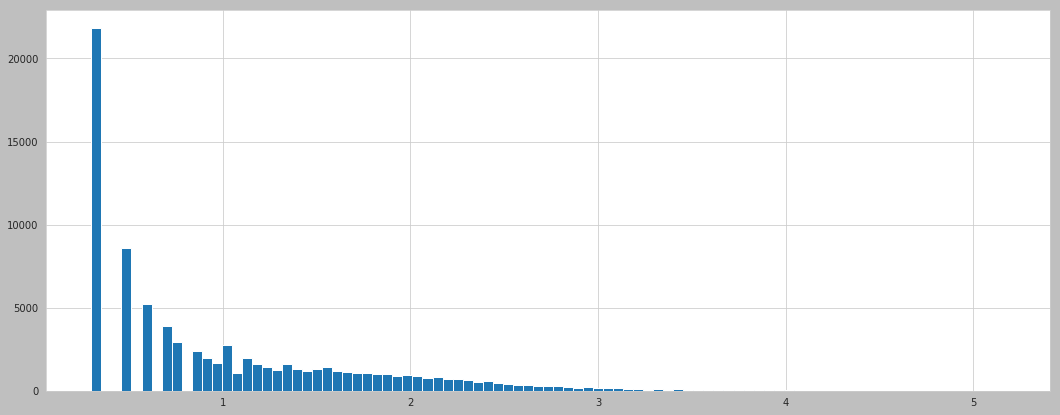

In [20]:
df[df['Starred'] > 0]['Starred'].map(lambda x: np.log10(x + 1)).hist(bins='auto');

In [21]:
df['Branch'].value_counts()

master                        256308
develop                          994
gh-pages                         533
dev                              356
main                             214
development                       88
release                           85
devel                             68
trunk                             51
public                            35
kinetic-devel                     33
stable                            29
indigo-devel                      28
v2                                22
source                            21
hydro-devel                       20
next                              16
melodic-devel                     16
ssd                               14
pytorch                           13
regression                        13
banjin-dev                        13
rm                                13
2.0                               12
alpha                             12
staging                           11
metadata-v2                       11
r

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_converter.py:129: FutureWarning:

Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()



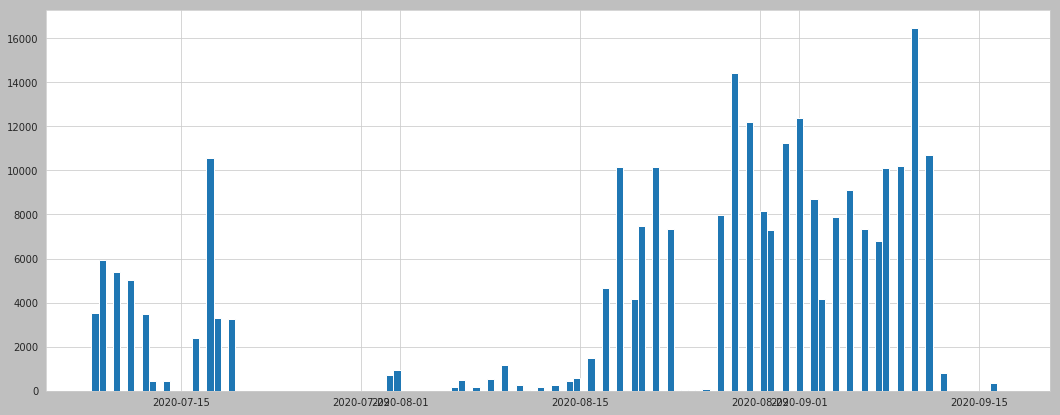

In [22]:
df['LastUpdate'].hist(bins='auto');